# 01 — Data audit

Reproduces every finding in `AUDIT.md` directly from the raw exports. Nothing
here is modified or written except `results/audit_findings.json`. Each section
states the finding, shows the evidence, and ends with an `assert` so that a
future export that no longer has the defect makes this notebook fail loudly
rather than silently report a stale conclusion.

| ID | Finding |
|---|---|
| F1 | Unmasked SoilGrids nodata diluted every soil band; the R² = 0.95 SOC model learned the dilution |
| F2 | `Grid_ID` is a random integer, not a cell key |
| F3 | MOD17 NPP is raw DN; the 0.0001 scale factor was never applied |
| F4 | Negative NPP values are genuine product values, not contamination |
| F5 | The 500 m NPP target is duplicated across 250 m cells |
| F6 | Four climate covariates are reconstructible from position alone |
| F8 | The old duplicate-ID rule deleted real, systematically less agricultural cells |
| S1 | The 20,000-cell training file is a simple random sample of the grid |

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import poisson
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config as C

RESULTS = C.RESULTS
RESULTS.mkdir(exist_ok=True)
findings = {}

bg_raw = pd.read_csv(C.DATA / "Below_Ground_Data_geom.csv")
ag_raw = pd.read_csv(C.DATA / "Above_ground_data_geom.csv")
bgd    = pd.read_csv(C.DATA / "BGD_for_all_grids(GEOM).csv")
agd    = pd.read_csv(C.DATA / "AGD_for_all_grids_geom.csv")
print("sample files:", bg_raw.shape, ag_raw.shape, "| full grid:", bgd.shape, agd.shape)

sample files: (20000, 9) (20000, 14) | full grid: (66700, 9) (66700, 14)


## 0. Structure: which files line up with which

In [2]:
geo_s = C.grid_rowcol(bg_raw["WKT"])
geo_g = C.grid_rowcol(bgd["WKT"])
bg_raw["cell_id"] = C.cell_key(geo_s.grid_row, geo_s.grid_col).to_numpy()
bgd["cell_id"] = C.cell_key(geo_g.grid_row, geo_g.grid_col).to_numpy()
bg_raw[["lon", "lat"]] = geo_s[["lon", "lat"]].to_numpy()
bgd[["lon", "lat"]] = geo_g[["lon", "lat"]].to_numpy()

structure = {
    "sample_files_row_aligned": bool((bg_raw.WKT.values == ag_raw.WKT.values).all()),
    "grid_files_row_aligned": bool((bgd.WKT.values == agd.WKT.values).all()),
    "grid_polygons_unique": int(bgd.WKT.nunique()),
    "grid_cell_ids_unique": int(bgd.cell_id.nunique()),
    "sample_cells_in_grid": int(bg_raw.cell_id.isin(bgd.cell_id).sum()),
}
m = bg_raw[["cell_id", "Grid_ID"]].merge(bgd[["cell_id", "Grid_ID"]], on="cell_id", suffixes=("_s", "_g"))
structure["sample_and_grid_share_Grid_ID"] = bool((m.Grid_ID_s == m.Grid_ID_g).all())
for k, v in structure.items():
    print(f"{k:35s} {v}")
assert structure["grid_cell_ids_unique"] == C.N_GRID_CELLS
assert structure["sample_cells_in_grid"] == len(bg_raw)
findings["structure"] = structure

sample_files_row_aligned            True
grid_files_row_aligned              True
grid_polygons_unique                66700
grid_cell_ids_unique                66700
sample_cells_in_grid                20000
sample_and_grid_share_Grid_ID       True


## F2 — `Grid_ID` is a random integer

If IDs were drawn uniformly from N = 10⁶ values, n draws would give
N·(1 − (1 − 1/N)ⁿ) distinct values and a Poisson multiplicity spectrum. A
pipeline bug does not produce that signature; a random column does.

In [3]:
n, N = len(bgd), 1_000_000
vc = bgd.Grid_ID.value_counts()
expected_distinct = N * (1 - (1 - 1 / N) ** n)
lam = n / N
mult_obs = vc.value_counts().sort_index()
mult_exp = {k: N * poisson.pmf(k, lam) for k in mult_obs.index}

print(f"rows {n:,}, unique polygons {bgd.WKT.nunique():,}, unique Grid_IDs {bgd.Grid_ID.nunique():,}")
print(f"expected distinct under uniform draw: {expected_distinct:,.0f}")
print("\nmultiplicity  observed  Poisson-expected")
for k in mult_obs.index:
    print(f"  x{k}          {mult_obs[k]:7,}   {mult_exp[k]:9,.0f}")
dec = pd.cut(bgd.Grid_ID, np.linspace(0, N, 11)).value_counts().sort_index()
print(f"\nper-decile counts over [0, 1e6): min {dec.min():,}  max {dec.max():,}  (uniform: {n / 10:,.0f})")

pair = vc[vc == 2].index[0]
print(f"\nexample: Grid_ID {pair} labels two cells", bgd.loc[bgd.Grid_ID == pair, ["cell_id", "lon", "lat"]].round(4).values.tolist())

findings["F2_grid_id"] = {
    "rows": n, "unique_ids": int(bgd.Grid_ID.nunique()), "expected_distinct": round(expected_distinct),
    "cells_lost_to_dedup": int(n - bgd.Grid_ID.nunique()),
    "multiplicity_observed": {int(k): int(v) for k, v in mult_obs.items()},
    "multiplicity_expected": {int(k): round(v) for k, v in mult_exp.items()},
}
assert abs(bgd.Grid_ID.nunique() - expected_distinct) / expected_distinct < 0.002

rows 66,700, unique polygons 66,700, unique Grid_IDs 64,545
expected distinct under uniform draw: 64,524

multiplicity  observed  Poisson-expected
  x1           62,431      62,396
  x2            2,075       2,081
  x3               37          46
  x4                2           1

per-decile counts over [0, 1e6): min 6,537  max 6,796  (uniform: 6,670)

example: Grid_ID 411542 labels two cells [['r13784_c33553', 75.3541, 30.9571], ['r13645_c33619', 75.5023, 30.6449]]


## F8 — the old duplicate rule deleted real, less-agricultural cells

The notebook kept the row with the highest `Ag/NonAg_m` per `Grid_ID`. Since
the "duplicates" are distinct cells, that rule deleted 2,155 real cells and
biased what survived.

In [4]:
srt = bgd.sort_values("Ag/NonAg_m", ascending=False)
kept = srt.drop_duplicates("Grid_ID")
dropped = srt[~srt.index.isin(kept.index)]
in_groups = bgd[bgd.Grid_ID.isin(vc[vc > 1].index)]
kept_g = kept[kept.Grid_ID.isin(vc[vc > 1].index)]
ties = in_groups.groupby("Grid_ID")["Ag/NonAg_m"].nunique().eq(1).sum()
area = C.cell_areas_ha(bgd.WKT)
f8 = {
    "cells_deleted": len(dropped),
    "deleted_mean_ag_frac": round(dropped["Ag/NonAg_m"].mean(), 3),
    "deleted_agri_share": round(dropped.agri_class.mean(), 3),
    "kept_in_collision_groups_mean_ag_frac": round(kept_g["Ag/NonAg_m"].mean(), 3),
    "kept_in_collision_groups_agri_share": round(kept_g.agri_class.mean(), 3),
    "groups_decided_by_sort_order": int(ties),
    "grid_area_full_ha": round(area.sum(), 1),
    "grid_area_after_dedup_ha": round(area[kept.index].sum(), 1),
}
for k, v in f8.items():
    print(f"{k:42s} {v}")
findings["F8_dedup_bias"] = f8

cells_deleted                              2155
deleted_mean_ag_frac                       0.654
deleted_agri_share                         0.677
kept_in_collision_groups_mean_ag_frac      0.95
kept_in_collision_groups_agri_share        0.97
groups_decided_by_sort_order               596
grid_area_full_ha                          356893.9
grid_area_after_dedup_ha                   345364.3


## S1 — the training file behaves as a simple random sample

The sample fraction is the same (≈ 0.30) in every land class, soil class and
region, and covariate means are indistinguishable from the unsampled cells.
Balance checks cannot prove randomness, but they are what a simple random
sample would produce, and they justify design-based (survey) estimation of
district totals without a predictive model.

In [5]:
bgd["sampled"] = bgd.cell_id.isin(bg_raw.cell_id)
by_region = bgd.groupby([pd.qcut(bgd.lon, 5, labels=False), pd.qcut(bgd.lat, 5, labels=False)]).sampled.mean()
s1 = {
    "sample_fraction": round(bgd.sampled.mean(), 4),
    "fraction_by_agri_class": bgd.groupby("agri_class").sampled.mean().round(4).to_dict(),
    "fraction_by_soil_class": bgd.groupby(C.soil_qc(bgd.BD_g_cm3)["soil_status"].to_numpy()).sampled.mean().round(4).to_dict(),
    "fraction_5x5_regions_min": round(by_region.min(), 3),
    "fraction_5x5_regions_max": round(by_region.max(), 3),
    "mean_DEM_sampled_vs_not": [round(bgd.loc[bgd.sampled, "DEM_mean"].mean(), 2), round(bgd.loc[~bgd.sampled, "DEM_mean"].mean(), 2)],
    "mean_BD_sampled_vs_not": [round(bgd.loc[bgd.sampled, "BD_g_cm3"].mean(), 4), round(bgd.loc[~bgd.sampled, "BD_g_cm3"].mean(), 4)],
}
for k, v in s1.items():
    print(f"{k:32s} {v}")
findings["S1_random_sample"] = s1
assert 0.27 < s1["fraction_5x5_regions_min"] and s1["fraction_5x5_regions_max"] < 0.33

sample_fraction                  0.2999
fraction_by_agri_class           {0: 0.3015, 1: 0.2995}
fraction_by_soil_class           {'full': 0.2994, 'nodata': 0.2948, 'partial': 0.308}
fraction_5x5_regions_min         0.286
fraction_5x5_regions_max         0.32
mean_DEM_sampled_vs_not          [np.float64(245.66), np.float64(245.72)]
mean_BD_sampled_vs_not           [np.float64(1.3842), np.float64(1.3857)]


## F1 — unmasked nodata diluted every soil band

A cell that is a fraction *w* valid reports *w* × (true value) in every band.
Three predictions follow, and all three hold: zeros co-occur across bands;
ratios between bands are unchanged in diluted cells; and the dilution creates
strong positive correlations between bands that are physically negatively
related.

In [6]:
soil = ["sand_pct", "clay_pct", "bd_gcm3", "SOC_mean"]
qc = C.soil_qc(bg_raw.bd_gcm3)
bg_raw[["soil_status", "w_soil"]] = qc[["soil_status", "w_soil"]].to_numpy()
bg_raw["w_soil"] = bg_raw["w_soil"].astype(float)
full = bg_raw[bg_raw.soil_status == "full"]
part = bg_raw[(bg_raw.bd_gcm3 > 0) & (bg_raw.bd_gcm3 < C.BD_VALID_MIN)]
zero = bg_raw[bg_raw.bd_gcm3 == 0]

print("rows with every soil band exactly 0:", int((bg_raw[soil] == 0).all(axis=1).sum()))
print(f"full {len(full):,} | partially diluted {len(part):,} | zero BD {len(zero):,}")
print(f"undiluted BD: median {full.bd_gcm3.median():.3f}, sd {full.bd_gcm3.std():.3f} g/cm3")
print(f"zero-BD cells that are non-agricultural: {(zero.agri_class == 0).mean():.1%}  (n={len(zero)})")

ratios = pd.DataFrame({
    "undiluted": [(full.sand_pct / full.bd_gcm3).median(), (full.SOC_mean / full.bd_gcm3).median(), (full.clay_pct / full.bd_gcm3).median()],
    "partially diluted": [(part.sand_pct / part.bd_gcm3).median(), (part.SOC_mean / part.bd_gcm3).median(), (part.clay_pct / part.bd_gcm3).median()],
}, index=["sand / BD", "SOC / BD", "clay / BD"]).round(2)
print("\nBand ratios are invariant to dilution:\n", ratios)

rec = bg_raw[bg_raw.soil_status != "nodata"].copy()
for c in soil:
    rec[c] = C.undilute(rec[c], rec.w_soil)

def corr_pairs(d):
    return {"sand x clay": d.sand_pct.corr(d.clay_pct), "BD x SOC": d.bd_gcm3.corr(d.SOC_mean),
            "clay x SOC": d.clay_pct.corr(d.SOC_mean), "sand x SOC": d.sand_pct.corr(d.SOC_mean)}

corr = pd.DataFrame({"as extracted": corr_pairs(bg_raw), "undiluted cells only": corr_pairs(full),
                     "after recovery (value / w)": corr_pairs(rec)}).round(3)
print("\n", corr)
findings["F1_dilution"] = {
    "all_bands_zero_rows": int((bg_raw[soil] == 0).all(axis=1).sum()),
    "full": len(full), "partial": len(part), "zero_bd": len(zero),
    "bd_full_median": round(full.bd_gcm3.median(), 3), "bd_full_sd": round(full.bd_gcm3.std(), 4),
    "ratios": ratios.to_dict(), "correlations": corr.to_dict(),
}
assert corr.loc["sand x clay", "as extracted"] > 0.5 and corr.loc["sand x clay", "undiluted cells only"] < -0.3

rows with every soil band exactly 0: 773
full 17,691 | partially diluted 1,527 | zero BD 782
undiluted BD: median 1.500, sd 0.024 g/cm3
zero-BD cells that are non-agricultural: 98.5%  (n=782)

Band ratios are invariant to dilution:
            undiluted  partially diluted
sand / BD      24.92              25.66
SOC / BD       20.51              19.48
clay / BD      18.45              17.64

              as extracted  undiluted cells only  after recovery (value / w)
sand x clay         0.839                -0.674                      -0.667
BD x SOC            0.966                -0.266                      -0.245
clay x SOC          0.950                 0.325                       0.373
sand x SOC          0.896                -0.353                      -0.352


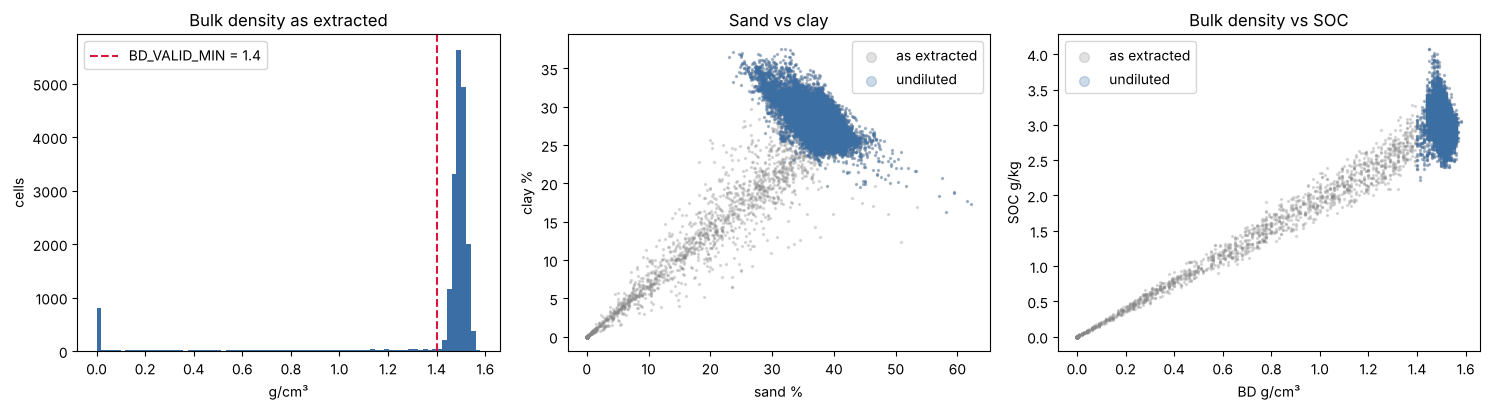

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].hist(bg_raw.bd_gcm3, bins=80, color="#3b6ea5")
ax[0].axvline(C.BD_VALID_MIN, color="crimson", ls="--", label=f"BD_VALID_MIN = {C.BD_VALID_MIN}")
ax[0].set(title="Bulk density as extracted", xlabel="g/cm³", ylabel="cells"); ax[0].legend()
ax[1].scatter(bg_raw.sand_pct, bg_raw.clay_pct, s=2, alpha=.25, color="#888", label="as extracted")
ax[1].scatter(full.sand_pct, full.clay_pct, s=2, alpha=.25, color="#3b6ea5", label="undiluted")
ax[1].set(title="Sand vs clay", xlabel="sand %", ylabel="clay %"); ax[1].legend(markerscale=5)
ax[2].scatter(bg_raw.bd_gcm3, bg_raw.SOC_mean * C.SOC_DGKG_TO_GKG, s=2, alpha=.25, color="#888", label="as extracted")
ax[2].scatter(full.bd_gcm3, full.SOC_mean * C.SOC_DGKG_TO_GKG, s=2, alpha=.25, color="#3b6ea5", label="undiluted")
ax[2].set(title="Bulk density vs SOC", xlabel="BD g/cm³", ylabel="SOC g/kg"); ax[2].legend(markerscale=5)
plt.tight_layout(); plt.savefig(RESULTS / "fig_F1_dilution.png", dpi=130); plt.show()

### F1 consequence — the SOC model learned the dilution

Identical random-forest settings, five-fold random and 8 × 8 spatial-block
cross-validation. On undiluted cells the skill collapses while RMSE barely
moves: the high R² came from variance the dilution created.

In [8]:
bg_raw["soc_gkg"] = bg_raw.SOC_mean * C.SOC_DGKG_TO_GKG
FEATS = ["agri_class", "DEM_mean", "Slope_mean", "sand_pct", "clay_pct", "bd_gcm3"]
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=C.RANDOM_STATE)

def evaluate(d, feats, label):
    X, y = d[feats].to_numpy(), d.soc_gkg.to_numpy()
    p_rand = cross_val_predict(rf, X, y, cv=KFold(C.N_FOLDS, shuffle=True, random_state=C.RANDOM_STATE))
    p_spat = cross_val_predict(rf, X, y, cv=GroupKFold(C.N_FOLDS), groups=C.spatial_blocks(d.lon, d.lat))
    return {"configuration": label, "n": len(d), "target sd": y.std(),
            "R2 random": r2_score(y, p_rand), "R2 spatial": r2_score(y, p_spat),
            "RMSE spatial": mean_squared_error(y, p_spat) ** 0.5, "MAE spatial": mean_absolute_error(y, p_spat)}

full = bg_raw[bg_raw.soil_status == "full"]
rows = [
    evaluate(bg_raw, FEATS, "as extracted, 6 features"),
    evaluate(bg_raw, ["bd_gcm3"], "as extracted, BD alone"),
    evaluate(full, FEATS, "undiluted, 6 features"),
    evaluate(full, ["bd_gcm3"], "undiluted, BD alone"),
    evaluate(full, ["agri_class", "DEM_mean", "Slope_mean"], "undiluted, terrain + class"),
    evaluate(full, ["lon", "lat"], "undiluted, coordinates only"),
]
exp = pd.DataFrame(rows).set_index("configuration").round(3)
print(exp.to_string())
findings["F1_model_experiment"] = exp.reset_index().to_dict(orient="records")
assert exp.loc["as extracted, 6 features", "R2 spatial"] > 0.9 > 0.4 > exp.loc["undiluted, 6 features", "R2 spatial"]

                                 n  target sd  R2 random  R2 spatial  RMSE spatial  MAE spatial
configuration                                                                                  
as extracted, 6 features     20000      0.765      0.968       0.955         0.163        0.120
as extracted, BD alone       20000      0.765      0.951       0.950         0.172        0.128
undiluted, 6 features        17691      0.187      0.429       0.191         0.168        0.129
undiluted, BD alone          17691      0.187      0.115       0.092         0.178        0.137
undiluted, terrain + class   17691      0.187      0.025      -0.089         0.195        0.148
undiluted, coordinates only  17691      0.187      0.774       0.158         0.172        0.129


## F3 — MOD17 NPP is stored DN, never scaled

MOD17A3HGF stores `Npp` as integers with scale 0.0001 kgC/m² (valid range
−30,000 to 32,700). The column holds integers in exactly that form.

In [9]:
y = ag_raw.Agricultur
v = y.dropna()
f3 = {
    "non_null": int(v.size), "missing": int(y.isna().sum()),
    "integer_fraction": round(float((v == v.round()).mean()), 4),
    "min": float(v.min()), "max": float(v.max()), "median": float(v.median()),
    "median_gC_m2_yr_if_DN": round(float(v.median()) * C.NPP_DN_TO_GC_M2_YR, 1),
    "old_tC_ha_yr_at_median (DN/100)": round(float(v.median()) / 100, 3),
    "correct_tC_ha_yr_at_median (DN/1000)": round(float(v.median()) * C.NPP_DN_TO_TC_HA_YR, 3),
}
for k, val in f3.items():
    print(f"{k:40s} {val}")
print("\nNon-integer values arise where a 250 m cell straddles 500 m MODIS pixels and the mean blends them.")
findings["F3_npp_scale"] = f3
assert f3["integer_fraction"] > 0.7 and f3["max"] > 100

non_null                                 17038
missing                                  2962
integer_fraction                         0.7739
min                                      -3687.0
max                                      2846.0
median                                   1203.0
median_gC_m2_yr_if_DN                    120.3
old_tC_ha_yr_at_median (DN/100)          12.03
correct_tC_ha_yr_at_median (DN/1000)     1.203

Non-integer values arise where a 250 m cell straddles 500 m MODIS pixels and the mean blends them.


## F4 — negative NPP is real product output, not contamination

The earlier review attributed the negative tail to fill values mixed into the
mean. The data refute that: negatives are as often exact integers as
positives, form a continuous distribution, and cluster spatially at distances
beyond a single MODIS pixel. They are
MOD17's own values — and negative annual NPP in irrigated double-cropped
fields is itself evidence that MOD17 is unreliable here (see the pipeline's
yield-based cross-check).

In [10]:
ag_raw[["lon", "lat"]] = bg_raw[["lon", "lat"]].to_numpy()
neg, pos = v[v < 0], v[v > 0]
valid = ag_raw[ag_raw.Agricultur.notna()].reset_index(drop=True)
xy = np.c_[valid.lon * 95_600, valid.lat * 110_600]          # metres, local approximation
s = valid.Agricultur.to_numpy()
# Neighbours 0.75-2 km away: outside the cell's own 500 m MODIS pixel, so shared
# pixel values (F5) cannot create the clustering.
pairs = cKDTree(xy).query_pairs(r=2000, output_type="ndarray")
dist = np.hypot(*(xy[pairs[:, 0]] - xy[pairs[:, 1]]).T)
far = pairs[dist > 750]
neg_i = np.r_[far[:, 0], far[:, 1]]
neg_j = np.r_[far[:, 1], far[:, 0]]
from_neg = s[neg_i] < 0
f4 = {
    "negative_cells": int(neg.size),
    "negative_share_of_agri_cells": round(float((ag_raw.loc[ag_raw.agri_class == 1, "Agricultur"].dropna() < 0).mean()), 3),
    "integer_fraction_negative": round(float((neg == neg.round()).mean()), 3),
    "integer_fraction_positive": round(float((pos == pos.round()).mean()), 3),
    "P(neighbour 0.75-2 km negative | negative)": round(float((s[neg_j][from_neg] < 0).mean()), 3),
    "base_rate_negative": round(float((s < 0).mean()), 3),
    "missing_share_non_agricultural": round(float((ag_raw.loc[y.isna(), "agri_class"] == 0).mean()), 3),
}
for k, val in f4.items():
    print(f"{k:44s} {val}")
print("\nIf negatives came from fill values mixed into cell means, they would be non-integers and")
print("isolated; MOD17 fill classes are +32761..32767 and would push values up, not down.")
findings["F4_negative_npp"] = f4
assert f4["P(neighbour 0.75-2 km negative | negative)"] > 2 * f4["base_rate_negative"]

negative_cells                               3179
negative_share_of_agri_cells                 0.198
integer_fraction_negative                    0.726
integer_fraction_positive                    0.785
P(neighbour 0.75-2 km negative | negative)   0.395
base_rate_negative                           0.187
missing_share_non_agricultural               0.817

If negatives came from fill values mixed into cell means, they would be non-integers and
isolated; MOD17 fill classes are +32761..32767 and would push values up, not down.


## F5 — the 500 m target is duplicated across 250 m cells

Up to four sampled cells inherit one MODIS pixel's value. A random split puts
the exact test target in the training set for most rows.

In [11]:
counts = v.value_counts()
shared = v.map(counts) > 1
f5 = {"rows": int(v.size), "distinct_values": int(v.nunique()),
      "rows_sharing_target_with_another": int(shared.sum()),
      "share": round(float(shared.mean()), 3)}
print(f5)
findings["F5_duplicate_target"] = f5

{'rows': 17038, 'distinct_values': 7378, 'rows_sharing_target_with_another': 12503, 'share': 0.734}


## F6 — climate covariates are position proxies

Each covariate is fitted from longitude and latitude alone (5-fold random CV).
Values near 1 mean the layer is a smooth interpolated surface that carries no
information at 250 m beyond *where* the cell is.

In [12]:
cov = ["Kharif_Pre", "LST_Sept20", "Rabi_Preci", "Rabi_LST_2", "DEM_mean", "Kharif_pea", "Rabi_Peak_", "Kharif_Lud", "NDWI_Rabi_", "Slope_mean"]
XY = ag_raw[["lon", "lat"]].to_numpy()
prox = {}
for c in cov:
    t = ag_raw[c].fillna(ag_raw[c].median()).to_numpy()
    p = cross_val_predict(RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=C.RANDOM_STATE), XY, t,
                          cv=KFold(5, shuffle=True, random_state=C.RANDOM_STATE))
    prox[c] = round(r2_score(t, p), 4)
prox = pd.Series(prox).sort_values(ascending=False)
print(prox.to_string())
findings["F6_position_proxies"] = prox.to_dict()
assert all(prox[c] > 0.95 for c in C.POSITION_PROXIES)

Kharif_Pre    0.9999
LST_Sept20    0.9999
Rabi_Preci    0.9999
Rabi_LST_2    0.9809
DEM_mean      0.8000
Kharif_Lud    0.6868
NDWI_Rabi_    0.6514
Kharif_pea    0.6240
Rabi_Peak_    0.6125
Slope_mean    0.5628


In [13]:
(RESULTS / "audit_findings.json").write_text(json.dumps(findings, indent=2, default=float))
print("Wrote", RESULTS / "audit_findings.json")

Wrote results/audit_findings.json
